## Catastro Minero de Salta

### Notebook 01: EDA y Limpieza de Datos

### Proyecto: Análisis del catastro minero oficial de la provincia de Salta, Argentina

Fuente: Geoportal oficial de Salta

###Autora: Camila Mopty
#### Fecha: 2026
--------------------------------------------

## 1. Librerías

In [1]:
#LIBRERÍAS

import subprocess
import os
import warnings
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from pathlib import Path
from datetime import datetime

import geopandas as gpd
from shapely.validation import make_valid

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import folium

from google.colab import files
from io import StringIO

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

## 2. Carga de dataset

In [2]:
# Clonación del repositorio

repo_url = "https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git"
repo_name = "catastro-minero-salta-mining-registry-salta"

if not os.path.exists(repo_name):
    subprocess.run(["git", "clone", repo_url], check=True)
    print("Repositorio clonado correctamente.")
else:
    print("El repositorio ya existe en el entorno.")

# Rutas
data_raw = f"https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git/data/raw/"
shapefile = f"https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git/data/raw/poligonos_adaf55f39328ff45c8c60e94eb13a7a0.shp"

Repositorio clonado correctamente.


In [3]:
import subprocess, sys

packages = [
    'geopandas',
    'pyproj',
    'folium',
    'missingno',
    'mapclassify',
    'fiona'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✓ Todas las dependencias instaladas correctamente.')

✓ Todas las dependencias instaladas correctamente.


In [4]:
# Leer el shapefile
catastro_minero = gpd.read_file("catastro-minero-salta-mining-registry-salta/data/raw/poligonos_adaf55f39328ff45c8c60e94eb13a7a0.shp",
encoding='latin-1'
)

# Verificar CRS (sistema de coordenadas)
print(catastro_minero.crs)

# Convertir a WGS84 si no está ya
cmin = catastro_minero.to_crs(epsg=4326)

# Exportar a GeoJSON (mantiene geometría)
#catastro_minero.to_file("catastro_minero.geojson", driver="GeoJSON")

# Exportar a CSV (sin geometría, para tablas relacionales)
#catastro_minero.drop(columns="geometry").to_csv("catastro_minero.csv", index=False)

EPSG:4326


## 3. EDA- Exploración inicial

In [116]:
cmin.shape

(4104, 16)

In [5]:
# Cantidad de columnas y filas del dataset

cmin.columns

Index(['fid', 'tipo', 'expediente', 'nombre', 'mineral', 'concesiona',
       'estado', 'resolucion', 'fecha_inic', 'departamen', 'municipio',
       'lugar', 'area', 'coordenada', 'geometry'],
      dtype='object')

In [6]:
cmin.geometry.geom_type.unique()

array(['Polygon', 'MultiPolygon'], dtype=object)

In [115]:
#Primeras columnas
cmin.head(5)

,fid,tipo,expediente,nombre,mineral,concesiona,estado,resolucion,fecha_inic,departamen,municipio,lugar,area,coordenada,geometry,area_ha
0,21613,Mina,21942,SALRIO 02,"Li,SALINAS",WOMBAT MINERALS S.A.,Vigente,None,2013-03-08,LOS ANDES,TOLAR GRANDE,SALAR DE RÍO GRANDE,"298,2633 ha","MULTIPOLYGON(((2580964.89 7223128,2582213.04 7...","POLYGON ((-68.19725 -25.11323, -68.18488 -25.1...",298.2633
1,21614,Manifestacion,825595,LUCRIZARO 2,Li,OLIVER PERALTA LUCRECIA,Vigente,None,2023-09-08,LOS ANDES,TOLAR GRANDE,ARIZARO,"900,4227 ha","MULTIPOLYGON(((2633624.49 7227300,2636467.07 7...","POLYGON ((-67.67564 -25.07183, -67.64747 -25.0...",900.4227
2,21615,Cantera,23265,METAN VIEJO,ÁRIDOS,VIALMANI S.A.,Vigente,None,2017-09-25,METÁN,SAN JOSÉ DE METÁN,None,"24,5410 ha","MULTIPOLYGON(((3603884.84 7176937.43,3603849.5...","POLYGON ((-64.9665 -25.52872, -64.96685 -25.52...",24.5410
3,21616,Manifestacion,824686,LUCAS POZUELOS II,Cu,PERALTA WALTER LUCAS,Vigente,None,2023-08-31,LOS ANDES,SAN ANTONIO DE LOS COBRES,POZUELOS,"426,8000 ha","MULTIPOLYGON(((3424576 7294298,3424848 7294298...","POLYGON ((-66.74397 -24.47107, -66.74129 -24.4...",426.8000
4,21617,Mina,22869,GONZALO I,"Au,Cu",CORRIENTE ARGENTINA S.A.,Vigente,None,2016-12-28,LOS ANDES,TOLAR GRANDE,TACA TACA,"2094,9707 ha","MULTIPOLYGON(((2593248.37 7298440.68,2599897 7...","POLYGON ((-68.0805 -24.4327, -68.01494 -24.432...",2094.9707


In [119]:
# Tabla info
column_info = pd.DataFrame({
    'Column': cmin.columns,
    'Non-Null Count': cmin.count().values,
    'Dtype': cmin.dtypes.values
})

display(column_info)


,Column,Non-Null Count,Dtype
0,fid,4104,int32
1,tipo,4104,object
2,expediente,4102,object
3,nombre,4006,object
4,mineral,3500,object
5,concesiona,3747,object
6,estado,4104,object
7,resolucion,95,object
8,fecha_inic,3928,datetime64[ms]
9,departamen,4103,object


In [10]:
# Valores de tipo y de estado

print(f'Tipo: {cmin['tipo'].unique()}')
print(f'estado: {cmin['estado'].unique()}')


Tipo: ['Mina' 'Manifestacion' 'Cantera' 'Cateo' 'Grupo Minero' 'Convenio'
 'Servidumbre' 'Zona de Investigación Geológica Minera']
estado: ['Vigente' 'Vacante' 'Anulación de registro sin publicar (REMSa)'
 'Anulación de registro sin publicar']


El Código de Minería de la República Argentina, aprobado por Ley N° 1919 define:
###Tipo
- Cateo: Es un derecho temporal exclusivo para realizar trabajos de búsqueda y  prospección de minerales en un área determinada con excavaciones de prueba.
- Manifestación: Es el acto formal y técnico donde el cateador notifica el hallazgo de un yacimiento nuevo. Genera prioridad legal sobre el terreno para transformar el cateo en una concesión de mina.
- Mina: Es la propiedad minera propiamente dicha, concedida por el Estado de manera perpetua. Explotación de sustancias de primera y segunda categoría.
- Cantera:Explotación de sustancias de Tercera Categoría (minerales industriales, rocas de aplicación, arenas, piedras de construcción).
- Grupo Minero: Es la unificación catastral y operativa de dos o más pertenencias de minas contiguas para ser explotadas bajo un único plan de trabajos unificado.
- Servidumbre: Derecho de ocupación o uso que la ley le concede al minero sobre los terrenos superficiales para caminos de acceso, acueductos, tendidos eléctricos o campamentos, con previa indemnización al propietario.
- Zona de Investigación Geológica Minera: Áreas reservadas temporalmente por el Estado (o corporaciones estatales delegadas) para que organismos oficiales de investigación geológica realicen prospecciones a gran escala. Durante la vigencia de esta zona, queda suspendida la admisión de peticiones de cateos o manifestaciones de descubrimiento por parte de particulares.

###Estado
- Vigente: El derecho minero se encuentra plenamente activo y válido.
- Vacante: El derecho minero previo ha caducado, ha sido revocado o el plazo del cateo expiró y el área ya ha sido liberada formalmente mediante publicación en el Boletín Oficial.
- Anulación de registro sin publicar: La Autoridad Minera ya ha dictado la resolución  de caducidad o rechazo ese expediente pero aún no se ha publicado en el Boletín Oficial.
- Anulación de registro sin publicar (REMSa): una mina cae en caducidad y el Juzgado de Minas dicta la anulación del registro, pero el área no se libera para el público general sino que se transfiere preferencialmente a la empresa estatal REMSa S.A. para que esta evalúe su potencial y la someta a licitación o concurso público de proyectos.

In [122]:
# Cantidad y porcentaje de nulos por columna

nulos = pd.DataFrame({
    'nulos': cmin.isnull().sum(),
    'porcentaje':  (cmin.isnull().sum() / len(cmin) * 100).round(1),
}).sort_values('porcentaje', ascending=False)

print(nulos)

            nulos  porcentaje
resolucion   4009        97.7
mineral       604        14.7
lugar         567        13.8
concesiona    357         8.7
fecha_inic    176         4.3
nombre         98         2.4
municipio      54         1.3
expediente      2         0.0
estado          0         0.0
fid             0         0.0
tipo            0         0.0
departamen      1         0.0
area            0         0.0
coordenada      0         0.0
geometry        0         0.0
area_ha         0         0.0


## **4. Preparación y transformación del dataset**

In [12]:
# Transformación: campo 'area' a float
# Paso 1: eliminar 'ha' del final
# Paso 2: reemplazar ',' por '.'
# Paso 3: convertir a float

cmin['area_ha'] = (
    cmin['area']
    .str.replace(' ha', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Verificación
print("Muestra de conversión:")
comparacion = cmin[['area', 'area_ha']].dropna().head(8)
print(comparacion.to_string())
print(f"\nTipo de dato: {cmin['area_ha'].dtype}")
print(f"Nulos:        {cmin['area_ha'].isna().sum()}")
print(f"Rango:        {cmin['area_ha'].min():.2f} ha — {cmin['area_ha'].max():,.2f} ha")

Muestra de conversión:
           area    area_ha
0   298,2633 ha   298.2633
1   900,4227 ha   900.4227
2    24,5410 ha    24.5410
3   426,8000 ha   426.8000
4  2094,9707 ha  2094.9707
5   100,9902 ha   100.9902
6  2686,6520 ha  2686.6520
7  2405,3080 ha  2405.3080

Tipo de dato: float64
Nulos:        0
Rango:        0.01 ha — 80,031.94 ha


###Clasificación

In [13]:
# Creación de subconjunto para análisis de minerales
# Criterio: excluir registros donde 'mineral' es NaN o string vacío


cmin_completo = cmin[
    cmin['mineral'].notna() &
    (cmin['mineral'].str.strip() != '')
].copy()

# Verificación
print(f"Dataset completo:           {len(cmin):,} registros")
print(f"Dataset con mineral:        {len(cmin_completo):,} registros")
print(f"Registros excluidos:        {len(cmin) - len(cmin_completo):,}")

print(f"\nValores y conteo de 'mineral' en cmin_completo:")
print(cmin_completo['mineral'].value_counts().to_string())

Dataset completo:           4,104 registros
Dataset con mineral:        3,500 registros
Registros excluidos:        604

Valores y conteo de 'mineral' en cmin_completo:
mineral
ÁRIDOS                                                             501
Cu                                                                 335
Li                                                                 321
Au,Cu                                                              205
K,Li,SALINAS                                                       153
BORATOS                                                            144
DIATOMITAS                                                         119
BORATOS,Li                                                         102
Li,SALINAS                                                         100
K,Li                                                                99
Ag,Au,Cu                                                            96
BORATOS,K,Li                              

In [14]:
cmin_completo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 3500 entries, 0 to 4103
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fid         3500 non-null   int32         
 1   tipo        3500 non-null   object        
 2   expediente  3498 non-null   object        
 3   nombre      3428 non-null   object        
 4   mineral     3500 non-null   object        
 5   concesiona  3247 non-null   object        
 6   estado      3500 non-null   object        
 7   resolucion  90 non-null     object        
 8   fecha_inic  3366 non-null   datetime64[ms]
 9   departamen  3500 non-null   object        
 10  municipio   3499 non-null   object        
 11  lugar       3228 non-null   object        
 12  area        3500 non-null   object        
 13  coordenada  3500 non-null   object        
 14  geometry    3500 non-null   geometry      
 15  area_ha     3500 non-null   float64       
dtypes: datetime64[ms](1),

In [123]:
# Cantidad y porcentaje de nulos por columna set de datos con minerales

nulos = pd.DataFrame({
    'nulos': cmin_completo.isnull().sum(),
    'porcentaje':  (cmin_completo.isnull().sum() / len(cmin_completo) * 100).round(1),
}).sort_values('porcentaje', ascending=False)

print(nulos)

                    nulos  porcentaje
resolucion           3410        97.4
lugar                 272         7.8
concesiona            253         7.2
fecha_inic            134         3.8
nombre                 72         2.1
expediente              2         0.1
fid                     0         0.0
mineral                 0         0.0
tipo                    0         0.0
estado                  0         0.0
departamen              0         0.0
municipio               1         0.0
area                    0         0.0
coordenada              0         0.0
geometry                0         0.0
area_ha                 0         0.0
minerales_criticos      0         0.0


In [15]:
# Clasificación one-hot
# Detecta presencia de Li, Cu , Au en el campo mineral como palabras completas delimitadas por ',' o espacios o aisladas

mineral_col = cmin_completo['mineral'].fillna('')

cmin_completo['minerales_criticos'] = (
    mineral_col.str.contains(r'\bLi\b', case=False) |
    mineral_col.str.contains(r'\bCu\b', case=False) |
    mineral_col.str.contains(r'\bAu\b', case=False)
)

In [16]:
cmin_completo.head(5)

,fid,tipo,expediente,nombre,mineral,concesiona,estado,resolucion,fecha_inic,departamen,municipio,lugar,area,coordenada,geometry,area_ha,minerales_criticos
0,21613,Mina,21942,SALRIO 02,"Li,SALINAS",WOMBAT MINERALS S.A.,Vigente,None,2013-03-08,LOS ANDES,TOLAR GRANDE,SALAR DE RÍO GRANDE,"298,2633 ha","MULTIPOLYGON(((2580964.89 7223128,2582213.04 7...","POLYGON ((-68.19725 -25.11323, -68.18488 -25.1...",298.2633,True
1,21614,Manifestacion,825595,LUCRIZARO 2,Li,OLIVER PERALTA LUCRECIA,Vigente,None,2023-09-08,LOS ANDES,TOLAR GRANDE,ARIZARO,"900,4227 ha","MULTIPOLYGON(((2633624.49 7227300,2636467.07 7...","POLYGON ((-67.67564 -25.07183, -67.64747 -25.0...",900.4227,True
2,21615,Cantera,23265,METAN VIEJO,ÁRIDOS,VIALMANI S.A.,Vigente,None,2017-09-25,METÁN,SAN JOSÉ DE METÁN,None,"24,5410 ha","MULTIPOLYGON(((3603884.84 7176937.43,3603849.5...","POLYGON ((-64.9665 -25.52872, -64.96685 -25.52...",24.5410,False
3,21616,Manifestacion,824686,LUCAS POZUELOS II,Cu,PERALTA WALTER LUCAS,Vigente,None,2023-08-31,LOS ANDES,SAN ANTONIO DE LOS COBRES,POZUELOS,"426,8000 ha","MULTIPOLYGON(((3424576 7294298,3424848 7294298...","POLYGON ((-66.74397 -24.47107, -66.74129 -24.4...",426.8000,True
4,21617,Mina,22869,GONZALO I,"Au,Cu",CORRIENTE ARGENTINA S.A.,Vigente,None,2016-12-28,LOS ANDES,TOLAR GRANDE,TACA TACA,"2094,9707 ha","MULTIPOLYGON(((2593248.37 7298440.68,2599897 7...","POLYGON ((-68.0805 -24.4327, -68.01494 -24.432...",2094.9707,True


In [17]:
# Geometrías válidas

print(f"Válidas:   {cmin_completo.geometry.is_valid.sum()}")
print(f"Inválidas: {(~cmin_completo.is_valid).sum()}")
print(f"Vacías:    {cmin_completo.is_empty.sum()}")
print(f"Nulas:     {cmin_completo.isna().sum()}")

Válidas:   3498
Inválidas: 2
Vacías:    0
Nulas:     fid                      0
tipo                     0
expediente               2
nombre                  72
mineral                  0
concesiona             253
estado                   0
resolucion            3410
fecha_inic             134
departamen               0
municipio                1
lugar                  272
area                     0
coordenada               0
geometry                 0
area_ha                  0
minerales_criticos       0
dtype: int64


In [18]:
# Tratamiento de geometrias inválidas

from shapely.validation import explain_validity

mask_invalidas = ~cmin_completo.geometry.is_valid

for idx, row in cmin_completo[mask_invalidas].iterrows():
    print(f"fid: {row['fid']}")
    print(f"nombre:       {row['nombre']}")
    print(f"problema:     {explain_validity(row.geometry)}")
    print()

fid: 21536
nombre:       PLAYA
problema:     Self-intersection[-66.6787951639559 -24.7668254463655]

fid: 21555
nombre:       MARIDEL
problema:     Self-intersection[-66.7085658422087 -24.7671982461615]



In [19]:
#Como ambas tienen self-intersections (error de dibujo) se convierten a válidas

from shapely.validation import make_valid

mask_invalidas = ~cmin_completo.geometry.is_valid
cmin_completo.loc[mask_invalidas, 'geometry'] = (
    cmin_completo.loc[mask_invalidas, 'geometry']
    .apply(make_valid)
)
print(f"Inválidas: {(~cmin_completo.is_valid).sum()}")

Inválidas: 0


In [20]:
# Filtrado y creación de conjunto de datos con minerales criticos
# Criterio: Seleccionar pedimentos con minerales críticos (Li, Cu y/o Au)
cmin_critico = cmin_completo[
    cmin_completo['minerales_criticos'] == True
].copy()

# Verificación
print(f"Dataset completo:           {len(cmin):,} registros")
print(f"Dataset con mineral:        {len(cmin_completo):,} registros")
print(f"Dataset con minerales criticos: {len(cmin_critico):,} registros")
print(f"Registros excluidos:        {len(cmin_completo) - len(cmin_critico):,}")

print(f"\nValores y conteo de 'mineral' en cmin_critico:")
print(cmin_critico['mineral'].value_counts().to_string())

Dataset completo:           4,104 registros
Dataset con mineral:        3,500 registros
Dataset con minerales criticos: 2,181 registros
Registros excluidos:        1,319

Valores y conteo de 'mineral' en cmin_critico:
mineral
Cu                                                                 335
Li                                                                 321
Au,Cu                                                              205
K,Li,SALINAS                                                       153
BORATOS,Li                                                         102
Li,SALINAS                                                         100
K,Li                                                                99
Ag,Au,Cu                                                            96
BORATOS,K,Li                                                        85
Cu,Li                                                               60
Au                                                              

In [21]:
# Cuenta pedimentos con minerales críticos
cmin_critico.minerales_criticos.value_counts().T

,count
minerales_criticos,
True,2181


In [23]:
# Valores de tipo y de estado

print(f'Tipo: {cmin_critico['tipo'].unique()}')
print(f'estado: {cmin_critico['estado'].unique()}')

Tipo: ['Mina' 'Manifestacion']
estado: ['Vigente' 'Vacante' 'Anulación de registro sin publicar (REMSa)'
 'Anulación de registro sin publicar']


In [24]:
#Exportar set de datos con minerales críticos para el notebook_02

# Exportar a GeoJSON (mantiene geometría)
#cmin_critico.to_file("cmin_critico.geojson", driver="GeoJSON")

#from google.colab import files
#files.download("cmin_critico.geojson")

# Tablas resumen

In [25]:
def split_by_critical(df):
    return df[df['minerales_criticos'] == True], df[df['minerales_criticos'] == False]

crit, non_crit = split_by_critical(cmin_completo)

# Tablas resumen
def build_general_summary(crit, non_crit, total):
    return pd.DataFrame({
        'Indicador': ['Total pedimentos', 'Superficie total (ha)'],
        'Minerales críticos': [
            len(crit),
            round(crit['area_ha'].sum(), 2)
        ],
        'Sin minerales críticos': [
            len(non_crit),
            round(non_crit['area_ha'].sum(), 2)
        ],
        'Total': [
            len(total),
            round(total['area_ha'].sum(), 2)
        ]
    })

summary_general = build_general_summary(crit, non_crit, cmin_completo)

# por tipo
def build_breakdown(crit, non_crit, total, col):
    """
    Builds a cross-tabulation of `col` values for each mineral category.
    Uses outer join to preserve all values even if absent in one category.
    """
    c = crit[col].value_counts().rename('Minerales críticos')
    n = non_crit[col].value_counts().rename('Sin minerales críticos')
    t = total[col].value_counts().rename('Total')

    df = pd.concat([c, n, t], axis=1).fillna(0).astype(int)
    df.index.name = col.capitalize()
    return df.reset_index()

summary_tipo   = build_breakdown(crit, non_crit, cmin_completo, 'tipo')
summary_estado = build_breakdown(crit, non_crit, cmin_completo, 'estado')


def style_table(df, title):
    """Applies consistent styling: header color, alternating rows."""
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    styled = (
        df.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th',
             'props': [('background-color', '#4A4A4A'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center')]},
            {'selector': 'tr:nth-child(odd)',
             'props': [('background-color', '#E0E0E0'),
                       ('color', 'black')]},
            {'selector': 'tr:nth-child(even)',
             'props': [('background-color', '#CCCCCC'),
                       ('color', 'black')]}
        ])
        .format(precision=2)
        .hide(axis='index')
    )
    display(styled)

style_table(summary_general, "1 · Totales generales")
style_table(summary_tipo,    "2 · Distribución por tipo")
style_table(summary_estado,  "3 · Distribución por estado")


  1 · Totales generales


Indicador,Minerales críticos,Sin minerales críticos,Total
Total pedimentos,2181.00,1319.00,3500.00
Superficie total (ha),3093638.11,572858.84,3666496.95



  2 · Distribución por tipo


Tipo,Minerales críticos,Sin minerales críticos,Total
Mina,1183,444,1627
Manifestacion,998,215,1213
Cantera,0,494,494
Convenio,0,166,166



  3 · Distribución por estado


Estado,Minerales críticos,Sin minerales críticos,Total
Vigente,2075,1255,3330
Vacante,91,55,146
Anulación de registro sin publicar (REMSa),9,5,14
Anulación de registro sin publicar,6,4,10


In [26]:
from google.colab import files

# Exportar en GeoJSON y csv
# cmin_critico.to_file('catastro_minero_clean.geojson', driver='GeoJSON')
# files.download('catastro_minero_clean.geojson')

# cmin_critico.drop(columns='geometry').to_csv('catastro_minero_clean.csv', index=False)
# files.download('catastro_minero_clean.csv')

## 5. Gráficos

**5.1. Cantidad total de pedimentos según departamentos - gráfico de barras**

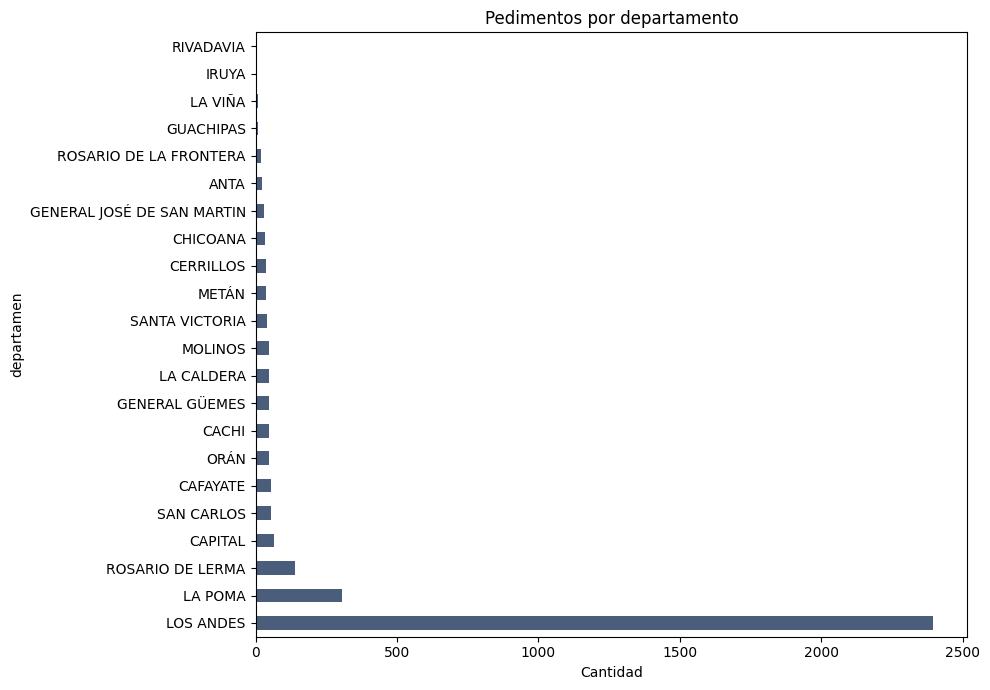

In [27]:
# Grafico 1 Distribución por departamentos grafico de barras
cmin_completo['departamen'].value_counts().plot(
    kind='barh', figsize=(10, 7), color='#4a5d7b'
)
plt.title('Pedimentos por departamento')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

**5.2. Cantidad total de pedimentos según departamentos - gráfico de tortas**

In [28]:
# Grafico 2: Pedimentos por departamentos en gráfico de tortas
exp_depto = (
    cmin_completo['departamen']
    .value_counts()
)

# Agrupar departamentos menores en 'Otros'
threshold = exp_depto.sum() * 0.03
otros = exp_depto[exp_depto < threshold].sum()
exp_depto_plot = exp_depto[exp_depto >= threshold].copy()
if otros > 0:
    exp_depto_plot['Otros'] = otros

fig = go.Figure(go.Pie(
    labels=exp_depto_plot.index,
    values=exp_depto_plot.values,
    hole=0,
    marker=dict(colors=['#4a5d7b', '#262134', '#899eac', '#3e4a38',
                         '#4a543c', '#8E44AD', '#C0392B']),
    textinfo='percent+label',
    textfont=dict(size=11),
))

fig.update_layout(
    title=dict(
        text='Cantidad de expedientes según departamento',
        font=dict(size=15, color='#2C3E50'),
        x=0.5
    ),
    legend=dict(orientation='v', x=1.05),
    margin=dict(t=60, b=20, l=20, r=150),
    width=600, height=420
)

fig.show()
fig.write_html('grafico de tortas departamento')

**5.3. Cantidad total de pedimentos con y sin minerales críticos - Gráfico de barras**

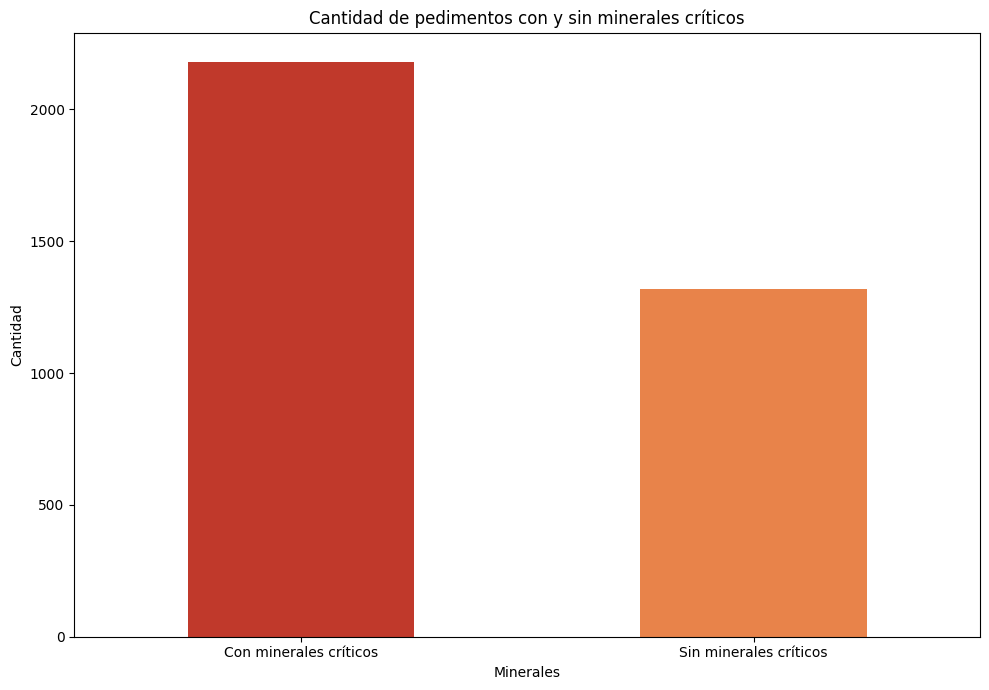

In [43]:
# Grafico 3: Pedimentos por departamentos en gráfico de tortas
counts = cmin_completo['minerales_criticos'].value_counts()
colors = {True: '#C0392B', False: '#E8834A'}
labels = {True: 'Con minerales críticos', False: 'Sin minerales críticos'}

plot_colors = [colors[idx] for idx in counts.index]
plot_labels = [labels[idx] for idx in counts.index]

counts.plot(
    kind='bar', figsize=(10, 7), color=plot_colors
)
plt.title('Cantidad de pedimentos con y sin minerales críticos')
plt.xlabel('Minerales')
plt.ylabel('Cantidad')
plt.xticks(ticks=[0, 1], labels=plot_labels, rotation=0)
plt.tight_layout()
plt.show()

**5.4. Pedimentos con y sin minerales críticos según área por departamento - gráfico de barras apiladas**

In [44]:
# Gráfico 4: Cantidad de pedimentos con y sin mínerales críticos (Li, Cu, Au) por departamento

sup_depto = (
    cmin_completo
    .groupby(['departamen', 'minerales_criticos'])['area_ha']
    .sum()
    .reset_index()
)

# Solo top 8 departamentos por superficie total
top_deptos = (
    cmin_completo.groupby('departamen')['area_ha']
    .sum()
    .nlargest(8)
    .index.tolist()
)

sup_depto_top = sup_depto[sup_depto['departamen'].isin(top_deptos)]

# Separar SI y NO
sup_si = sup_depto_top[sup_depto_top['minerales_criticos'] == True].set_index('departamen')['area_ha']
sup_no = sup_depto_top[sup_depto_top['minerales_criticos'] == False].set_index('departamen')['area_ha']

# Ordenar por superficie total descendente
orden = (sup_si.fillna(0) + sup_no.fillna(0)).sort_values(ascending=True).index

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales críticos (Li, Cu o Au)',
    y=orden,
    x=[sup_si.get(d, 0) for d in orden],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(orden),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=orden,
    x=[sup_no.get(d, 0) for d in orden],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(orden),
    textposition='inside'
))

# Etiquetas
for depto in orden:
    val_si = sup_si.get(depto, 0)
    val_no = sup_no.get(depto, 0)
    total  = val_si + val_no

    label_si = f"{val_si/1e6:.2f}M ha" if val_si >= 1e6 else f"{val_si:,.0f} ha".replace(',', '.')
    label_no = f"{val_no/1e6:.2f}M ha" if val_no >= 1e6 else f"{val_no:,.0f} ha".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=depto,
        text=f"<b>{label_si}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=1
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=depto,
        text=f"<b>{label_no}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=-1
    )

fig.update_layout(
    barmode='stack',
    separators='.',
    title=dict(
        text='Superficie (ha) con y sin minerales críticos por departamento',
        font=dict(size=15, color='#2C3E50'),
        x=0.15
    ),
    xaxis=dict(
        title='Hectáreas',
        tickformat=',.0f',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(title='', showgrid=False),
    legend=dict(orientation='h', y=-0.15),
    margin=dict(t=60, b=80, l=180, r=200),
    width=950, height=500,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
fig.write_html('grafico de barras superficie pedimentos con y sin minerales criticos por año ')

**5.5. Cantidad de Pedimentos con y sin mínerales críticos por año de iniciación (2009-2025) - Gráfico de barras apiladas**

In [63]:
# Gráfico 5: Cantidad de pedimentos por año de iniciación a partir de 2009

exp_anio = (
    cmin_completo[cmin_completo['fecha_inic'].notna()]
    .assign(anio=cmin_completo['fecha_inic'].dt.year)
    .query('anio >= 2009')
    .groupby(['anio', 'minerales_criticos'])
    .size()
    .reset_index(name='cantidad')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['cantidad']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['cantidad']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerale críticos (Li, Cu o Au)',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M" if val_con >= 1e6 else f"{val_con:,.0f}".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M" if val_sin >= 1e6 else f"{val_sin:,.0f}".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-4
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Cantidad de pedimentos por año con y sin minerales críticos',
        font=dict(size=15, color='#2C3E50'),
        x=0.05 # Changed x to 0.05 to add space to the left
    ),
    xaxis=dict(
        title='Cantidad de expedientes',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
fig.write_html('grafico de barras cantidad de pedimentos con y sin minerales criticos por año')

**5.6. Superficie de Pedimentos con y sin mínerales críticos por año de iniciación (2009-2025) - Gráfico de barras apiladas**

In [68]:
# Gráfico 6: Superficie (ha) de pedimentos por año de iniciación a partir de 2009

exp_anio = (
    cmin_completo[cmin_completo['fecha_inic'].notna()]
    .assign(anio=cmin_completo['fecha_inic'].dt.year)
    .query('anio >= 2009')
    .groupby(['anio', 'minerales_criticos'])['area_ha']
    .sum()
    .reset_index(name='area_total_ha')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['area_total_ha']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['area_total_ha']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales críticos (Li, Cu o Au)',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M ha" if val_con >= 1e6 else f"{val_con:,.0f} ha".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M ha" if val_sin >= 1e6 else f"{val_sin:,.0f} ha".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-1
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Superficie (ha) de pedimentos por año con y sin minerales críticos',
        font=dict(size=15, color='#2C3E50'),
        x=0.05 # Changed x to 0.05 to add space to the left
    ),
    xaxis=dict(
        title='Superficie (ha)',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
fig.write_html('grafico_barras_superficie_por_anio_con_sin_minerales_criticos.html')

**5.7. Cantidad de Pedimentos por tipo por año de iniciación (2009-2025) - Gráfico de barras apiladas**

In [30]:
cmin_completo.tipo.unique()

array(['Mina', 'Manifestacion', 'Cantera', 'Convenio'], dtype=object)

In [69]:
# Gráfico 7: Pedimentos según tipo por año (2009-2025)

# Filtrar datos por años y tipos específicos
selected_types = ['Mina', 'Manifestacion', 'Cantera', 'Convenio']

exp_anio_tipo = (
    cmin_completo[cmin_completo['fecha_inic'].notna()]
    .assign(anio=cmin_completo['fecha_inic'].dt.year)
    .query('2009 <= anio <= 2025') # Filter for years 2009 to 2025
    .groupby(['anio', 'tipo'])
    .size()
    .reset_index(name='cantidad')
)


exp_anio_tipo = exp_anio_tipo[exp_anio_tipo['tipo'].isin(selected_types)]
años = sorted(exp_anio_tipo['anio'].unique(), reverse=True)
tipos = sorted(exp_anio_tipo['tipo'].unique())

fig = go.Figure()

#Colores
colors_map = {
    'Mina': '#C0392B',          # Dark Red
    'Manifestacion': '#E8834A', # Orange
    'Cantera': '#3498DB',       # Blue
    'Convenio': '#27AE60'       # Green
}

for tipo_val in tipos:
    df_tipo = exp_anio_tipo[exp_anio_tipo['tipo'] == tipo_val].set_index('anio')['cantidad']
    fig.add_trace(go.Bar(
        name=tipo_val,
        y=años,
        x=[df_tipo.get(a, 0) for a in años],
        orientation='h',
        marker_color=colors_map.get(tipo_val, '#7F8C8D') # Default to grey if type not in map
    ))

cumulative_x = {a: 0 for a in años}

for tipo_val in tipos:
    df_tipo = exp_anio_tipo[exp_anio_tipo['tipo'] == tipo_val].set_index('anio')['cantidad']
    for anio_val in años:
        cantidad = df_tipo.get(anio_val, 0)
        if cantidad > 0:
            x_center = cumulative_x[anio_val] + cantidad / 2
            text_color = 'white' if tipo_val in ['Mina', 'Manifestacion', 'Convenio'] else 'black' # Adjusted for better contrast
            fig.add_annotation(
                x=x_center,
                y=anio_val,
                text=str(cantidad),
                showarrow=False,
                xanchor='center',
                yanchor='middle',
                font=dict(size=10, color=text_color)
            )
            cumulative_x[anio_val] += cantidad

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Expedientes por año (2009-2025) — por tipo de pedimento',
        font=dict(size=15, color='#2C3E50'),
        x=0.05
    ),
    xaxis=dict(
        title='Cantidad de expedientes',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12, x=0, xanchor='left'),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
fig.write_html('grafico_barras_pedimentos_por_tipo_anio_2009_2025.html')

**5.8. Cantidad de Pedimentos tipo Mina por año con y sin minerales críticos**

In [92]:
#Set de datos de pedimentos tipo 'Mina'

cmina = cmin_completo[cmin_completo['tipo'] == 'Mina']

In [93]:
# Gráfico 8: Cantidad de pedimentos tipo Mina por año con y sin minerales criticos

exp_anio = (
    cmina[cmin_completo['fecha_inic'].notna()]
    .assign(anio=cmin_completo['fecha_inic'].dt.year)
    .query('anio >= 2009')
    .groupby(['anio', 'minerales_criticos'])
    .size()
    .reset_index(name='cantidad')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['cantidad']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['cantidad']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales criticos',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M" if val_con >= 1e6 else f"{val_con:,.0f}".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M" if val_sin >= 1e6 else f"{val_sin:,.0f}".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-4
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Cantidad de pedimentos tipo Mina con y sin minerales críticos',
        font=dict(size=15, color='#2C3E50'),
        x=0.05 # Changed x to 0.05 to add space to the left
    ),
    xaxis=dict(
        title='Cantidad de expedientes',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
fig.write_html('grafico de barras cantidad de minas por año')

**5.9. Superficie de Pedimentos tipo Mina con y sin minerales criticos por año**

In [94]:
# Gráfico 9: Superficie (ha) de pedimentos tipo Mina por año con y sin minerales críticos

exp_anio = (
    cmina[cmina['fecha_inic'].notna()]
    .assign(anio=cmina['fecha_inic'].dt.year)
    .query('anio >= 2009') # Filter for years 2009 to 2025
    .groupby(['anio', 'minerales_criticos'])['area_ha']
    .sum()
    .reset_index(name='area_total_ha')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['area_total_ha']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['area_total_ha']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales críticos (Li, Cu o Au)',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M ha" if val_con >= 1e6 else f"{val_con:,.0f} ha".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M ha" if val_sin >= 1e6 else f"{val_sin:,.0f} ha".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-1
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Superficie (ha) de pedimentos tipo Mina con y sin minerales críticos por año',
        font=dict(size=15, color='#2C3E50'),
        x=0.05
    ),
    xaxis=dict(
        title='Hectáreas',
        tickformat=',.0f',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
fig.write_html('superficie tipo Mina con y son minerales criticos')

**5.10. Cantidad de Pedimentos tipo Manifestación por año con y sin minerales críticos**

In [95]:
#Set de datos de pedimentos tipo 'Manifestación'

cmanif = cmin_completo[cmin_completo['tipo'] == 'Manifestacion']

In [96]:
# Gráfico 10: Cantidad de pedimentos tipo Manifestación por año con y sin minerales criticos

exp_anio = (
    cmanif[cmanif['fecha_inic'].notna()] # Corrected to use cmanif's fecha_inic
    .assign(anio=lambda df: df['fecha_inic'].dt.year) # Corrected to use cmanif's fecha_inic
    .query('anio >= 2009')
    .groupby(['anio', 'minerales_criticos'])
    .size()
    .reset_index(name='cantidad')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['cantidad']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['cantidad']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales criticos',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M" if val_con >= 1e6 else f"{val_con:,.0f}".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M" if val_sin >= 1e6 else f"{val_sin:,.0f}".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-4
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Cantidad de pedimentos tipo Manifestación con y sin minerales críticos',
        font=dict(size=15, color='#2C3E50'),
        x=0.05 # Changed x to 0.05 to add space to the left
    ),
    xaxis=dict(
        title='Cantidad de expedientes',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
fig.write_html('Cantidad de pedimentos tipo Manifestación con y sin min criticos año')

**5.11. Superficie de Pedimentos tipo Manifestacion por departamento**

In [98]:
# Gráfico 11: Superficie (ha) de pedimentos tipo Manifestacion por departamento

exp_anio = (
    cmanif[cmanif['fecha_inic'].notna()]
    .assign(anio=cmanif['fecha_inic'].dt.year)
    .query('anio >= 2009') # Filter for years 2009 to 2025
    .groupby(['anio', 'minerales_criticos'])['area_ha']
    .sum()
    .reset_index(name='area_total_ha')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['area_total_ha']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['area_total_ha']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales críticos (Li, Cu o Au)',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M ha" if val_con >= 1e6 else f"{val_con:,.0f} ha".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M ha" if val_sin >= 1e6 else f"{val_sin:,.0f} ha".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-1
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Superficie (ha) de pedimentos tipo Manifestacion con y sin minerales críticos por año',
        font=dict(size=15, color='#2C3E50'),
        x=0.05
    ),
    xaxis=dict(
        title='Hectáreas',
        tickformat=',.0f',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
fig.write_html('superficie tipo Manifestación con y son minerales criticos')

**5.12. Localización de pedimentos con y sin minerales críticos - Mapa**

In [37]:
# Gráfico 12: Mapa localización de pedimentos con y sin minerales criticos

import geopandas as gpd
from shapely import wkt
import folium
from IPython.display import HTML

gdf = gpd.GeoDataFrame(
    cmin_completo[cmin_completo['geometry'].notna()].copy(),
    geometry=cmin_completo.loc[
        cmin_completo['geometry'].notna(), 'geometry'
    ],
    crs='EPSG:4326'
)


for col in gdf.select_dtypes(include=['datetime64']).columns:
    gdf[col] = gdf[col].astype(str)

# Definir colores
# #C0392B (dark red) = critical minerals
# #E8834A (orange) = without critical minerals
def style_function(feature):
    is_critical = feature['properties']['minerales_criticos']
    color = '#C0392B' if is_critical else '#E8834A'
    return {
        'fillColor': color,
        'color': color,
        'weight': 1,
        'fillOpacity': 0.6
    }

# Mapa centrado en Salta
center_lat = gdf.geometry.centroid.y.mean()
center_lon = gdf.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles='CartoDB positron'
)

# Agregar poligonos
folium.GeoJson(
    gdf,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['nombre', 'concesiona', 'mineral', 'minerales_criticos', 'fecha_inic'],
        aliases=['Nombre:', 'Titular:', 'Mineral:', 'Mineral crítico:', 'Fecha Inicio:'],
        sticky=True
    )
).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 6px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.3);
            font-family: Arial, sans-serif; font-size: 13px;">
    <b>Minerales críticos</b><br>
    <i style="background:#C0392B; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Sí<br>
    <i style="background:#E8834A; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> No
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

HTML(m._repr_html_())

Output hidden; open in https://colab.research.google.com to view.

**5.13. Localización de pedimentos según tipo con y sin minerales críticos - Mapa**

In [91]:
# Mapa localización de pedimentos según tipo con y sin minerales críticos
import geopandas as gpd
from shapely import wkt
import folium
from IPython.display import HTML

gdf = gpd.GeoDataFrame(
    cmin_completo[cmin_completo['geometry'].notna()].copy(),
    geometry=cmin_completo.loc[
        cmin_completo['geometry'].notna(), 'geometry'
    ],
    crs='EPSG:4326'
)


for col in gdf.select_dtypes(include=['datetime64']).columns:
    gdf[col] = gdf[col].astype(str)

# Definir colores para el relleno según el tipo de pedimento
fill_colors_map = {
    'Mina': '#854DF0',          # Violeta
    'Manifestacion': '#3498DB', # Azul
    'Cantera':  '#9E9DF0',      # Lila
    'Convenio': '#A6AB72'       # Verde
}

# Definir colores para el borde según si tiene minerales críticos
def style_function(feature):
    polygon_type = feature['properties']['tipo']
    is_critical = feature['properties']['minerales_criticos']

    fill_color = fill_colors_map.get(polygon_type, '#7F8C8D')
    border_color = '#C0392B' if is_critical else '#E8834A'

    return {
        'fillColor': fill_color,
        'color': border_color, # Border color
        'weight': 2, # Border thickness
        'fillOpacity': 0.6
    }

# Mapa centrado en Salta
center_lat = gdf.geometry.centroid.y.mean()
center_lon = gdf.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles='CartoDB positron'
)

# Agregar poligonos
folium.GeoJson(
    gdf,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['nombre', 'concesiona', 'mineral', 'tipo', 'minerales_criticos', 'fecha_inic'],
        aliases=['Nombre:', 'Titular:', 'Mineral:', 'Tipo:', 'Mineral crítico:', 'Fecha Inicio:'],
        sticky=True
    )
).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 6px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.3);
            font-family: Arial, sans-serif; font-size: 13px;">
    <b>Tipo de Pedimento (Relleno)</b><br>
    <i style="background:#854DF0; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Mina<br>
    <i style="background:#3498DB; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Manifestacion<br>
    <i style="background:#9E9DF0; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Cantera<br>
    <i style="background:#A6AB72; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Convenio<br>
    <br>
    <b>Minerales Críticos (Borde)</b><br>
    <i style="border: 2px solid #C0392B; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Sí<br>
    <i style="border: 2px solid #E8834A; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> No
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

HTML(m._repr_html_())

Output hidden; open in https://colab.research.google.com to view.

**5.14. Top 20 actores con pedimentos con minerales críticos según cantidad y superficie (ha)**

In [111]:
# Grafico 15: Top 20 actores por cantidad y superficie con minerales críticos
top20_exp = (
    cmin_critico[
        (cmin_critico['concesiona'].notna()) &
        (cmin_critico['concesiona'] != 'Vacancia Solicitada')
    ]
    .groupby('concesiona')
    .agg(
        expedientes=('concesiona', 'count'),
        ha=('area_ha', 'sum')
    )
    .reset_index()
    .nlargest(20, 'expedientes')
)

top20_exp['ha'] = top20_exp['ha'].astype(float)

# Capitalizar las etiquetas
top20_exp['concesiona_label'] = top20_exp['concesiona'].str.title()

def wrap_text_by_word(text, max_len):
    """Wraps text by words, inserting <br> for new lines."""
    words = text.split(' ')
    wrapped_text = []
    current_line = []
    current_len = 0
    for word in words:
        if current_len + len(word) + (1 if current_line else 0) > max_len:
            wrapped_text.append(' '.join(current_line))
            current_line = [word]
            current_len = len(word)
        else:
            current_line.append(word)
            current_len += len(word) + (1 if len(current_line) > 1 else 0)
    wrapped_text.append(' '.join(current_line))
    return '<br>'.join(wrapped_text)

top20_exp['concesiona_label_wrapped'] = top20_exp['concesiona_label'].apply(lambda x: wrap_text_by_word(x, 20))

fig = px.treemap(
    top20_exp,
    path=['concesiona_label_wrapped'], # Use the wrapped label for display
    values='expedientes',
    color='ha',
    color_continuous_scale='Oranges',
    range_color=[0, top20_exp['ha'].max()],
    title='Top 20 actores por superficie con minerales criticos',
    custom_data=['expedientes', 'ha', 'concesiona_label'], # Keep original label for hover
 )
fig.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} exp.',
    textfont=dict(size=11),
    hovertemplate=(
        '<b>%{customdata[2]}</b><br>' # Use original label in hover
        'Expedientes totales: %{customdata[0]}<br>'
        'Superficie total (ha): %{customdata[1]:,.0f}'
        '<extra></extra>'
    )
)
fig.update_layout(
    title=dict(font=dict(size=15, color='#2C3E50'), x=0.05),
    coloraxis_colorbar=dict(
        title=dict(
            text='Superficie total (ha)',
            font=dict(size=11, color='#2C3E50')
        ),
        tickfont=dict(size=10),
        thickness=15,
        len=0.8,
        x=1.02
    ),
    margin=dict(t=60, b=20, l=10, r=120),
    width=1500, height=500,
    showlegend=False
)
fig.show()
fig.write_html('tabla top 20 actores sup con minerales criticos')

**5.16. Top 20 actores con minerales críticos según cantidad de pedimentos tipo Mina**

In [112]:
# Grafico 16: Top 20 actores por superficie de pedimentos tipo Mina con minerales críticos
top20_exp = (
    cmina[
        (cmina['concesiona'].notna()) &
        (cmina['concesiona'] != 'Vacancia Solicitada')
    ]
    .groupby('concesiona')
    .agg(
        expedientes=('concesiona', 'count'),
        ha=('area_ha', 'sum')
    )
    .reset_index()
    .nlargest(20, 'ha')
)

top20_exp['ha'] = top20_exp['ha'].astype(float)

# Capitalizar las etiquetas
top20_exp['concesiona_label'] = top20_exp['concesiona'].str.title()

def wrap_text_by_word(text, max_len):
    """Wraps text by words, inserting <br> for new lines."""
    words = text.split(' ')
    wrapped_text = []
    current_line = []
    current_len = 0
    for word in words:
        if current_len + len(word) + (1 if current_line else 0) > max_len:
            wrapped_text.append(' '.join(current_line))
            current_line = [word]
            current_len = len(word)
        else:
            current_line.append(word)
            current_len += len(word) + (1 if len(current_line) > 1 else 0)
    wrapped_text.append(' '.join(current_line))
    return '<br>'.join(wrapped_text)

top20_exp['concesiona_label_wrapped'] = top20_exp['concesiona_label'].apply(lambda x: wrap_text_by_word(x, 20))

fig = px.treemap(
    top20_exp,
    path=['concesiona_label_wrapped'], # Use the wrapped label for display
    values='expedientes',
    color='ha',
    color_continuous_scale='Purples',
    range_color=[0, top20_exp['ha'].max()],
    title='Top 20 actores por superficie de pedimentos tipo Mina',
    custom_data=['expedientes', 'ha', 'concesiona_label'], # Keep original label for hover
 )
fig.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} exp.',
    textfont=dict(size=11),
    hovertemplate=(
        '<b>%{customdata[2]}</b><br>' # Use original label in hover
        'Expedientes totales: %{customdata[0]}<br>'
        'Superficie total (ha): %{customdata[1]:,.0f}'
        '<extra></extra>'
    )
)
fig.update_layout(
    title=dict(font=dict(size=15, color='#2C3E50'), x=0.05),
    coloraxis_colorbar=dict(
        title=dict(
            text='Superficie total (ha)',
            font=dict(size=11, color='#2C3E50')
        ),
        tickfont=dict(size=10),
        thickness=15,
        len=0.8,
        x=1.02
    ),
    margin=dict(t=60, b=20, l=10, r=120),
    width=1500, height=500,
    showlegend=False
)
fig.show()
fig.write_html('tabla top 20 actores mina superficie')

**5.17. Top 20 actores con minerales críticos según cantidad de pedimentos tipo Mina**

In [105]:
# Grafico 17: Top 20 actores por cantidad de pedimentos tipo Manifestación con minerales críticos
top20_exp = (
    cmanif[
        (cmanif['concesiona'].notna()) &
        (cmanif['concesiona'] != 'Vacancia Solicitada')
    ]
    .groupby('concesiona')
    .agg(
        expedientes=('concesiona', 'count'),
        criticos=('minerales_criticos', 'sum')
    )
    .reset_index()
    .nlargest(20, 'expedientes')
)

top20_exp['criticos'] = top20_exp['criticos'].astype(int)

# Capitalizar las etiquetas
top20_exp['concesiona_label'] = top20_exp['concesiona'].str.title()

def wrap_text_by_word(text, max_len):
    """Wraps text by words, inserting <br> for new lines."""
    words = text.split(' ')
    wrapped_text = []
    current_line = []
    current_len = 0
    for word in words:
        if current_len + len(word) + (1 if current_line else 0) > max_len:
            wrapped_text.append(' '.join(current_line))
            current_line = [word]
            current_len = len(word)
        else:
            current_line.append(word)
            current_len += len(word) + (1 if len(current_line) > 1 else 0)
    wrapped_text.append(' '.join(current_line))
    return '<br>'.join(wrapped_text)

top20_exp['concesiona_label_wrapped'] = top20_exp['concesiona_label'].apply(lambda x: wrap_text_by_word(x, 20))

fig = px.treemap(
    top20_exp,
    path=['concesiona_label_wrapped'], # Use the wrapped label for display
    values='expedientes',
    color='criticos',
    color_continuous_scale='YlOrRd',
    range_color=[0, top20_exp['criticos'].max()],
    title='Top 20 actores por cantidad de pedimentos tipo Manifestacion con minerales criticos',
    custom_data=['expedientes', 'criticos', 'concesiona_label'], # Keep original label for hover
 )
fig.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} exp.',
    textfont=dict(size=11),
    hovertemplate=(
        '<b>%{customdata[2]}</b><br>' # Use original label in hover
        'Expedientes totales: %{customdata[0]}<br>'
        'Con minerales críticos: %{customdata[1]}'
        '<extra></extra>'
    )
)
fig.update_layout(
    title=dict(font=dict(size=15, color='#2C3E50'), x=0.05),
    coloraxis_colorbar=dict(
        title=dict(
            text='Expedientes<br>con minerales<br>críticos',
            font=dict(size=11, color='#2C3E50')
        ),
        tickfont=dict(size=10),
        thickness=15,
        len=0.8,
        x=1.02
    ),
    margin=dict(t=60, b=20, l=10, r=120),
    width=1500, height=500,
    showlegend=False
)
fig.show()
fig.write_html('tabla top 20 actores tipo Manifestacion')

In [114]:
# Grafico 17: Top 20 actores por superficie de pedimentos tipo Manifestación con minerales críticos
top20_exp = (
    cmanif[
        (cmanif['concesiona'].notna()) &
        (cmanif['concesiona'] != 'Vacancia Solicitada')
    ]
    .groupby('concesiona')
    .agg(
        expedientes=('concesiona', 'count'),
        ha=('area_ha', 'sum')
    )
    .reset_index()
    .nlargest(20, 'ha')
)

top20_exp['ha'] = top20_exp['ha'].astype(float)

# Capitalizar las etiquetas
top20_exp['concesiona_label'] = top20_exp['concesiona'].str.title()

def wrap_text_by_word(text, max_len):
    """Wraps text by words, inserting <br> for new lines."""
    words = text.split(' ')
    wrapped_text = []
    current_line = []
    current_len = 0
    for word in words:
        if current_len + len(word) + (1 if current_line else 0) > max_len:
            wrapped_text.append(' '.join(current_line))
            current_line = [word]
            current_len = len(word)
        else:
            current_line.append(word)
            current_len += len(word) + (1 if len(current_line) > 1 else 0)
    wrapped_text.append(' '.join(current_line))
    return '<br>'.join(wrapped_text)

top20_exp['concesiona_label_wrapped'] = top20_exp['concesiona_label'].apply(lambda x: wrap_text_by_word(x, 20))

fig = px.treemap(
    top20_exp,
    path=['concesiona_label_wrapped'], # Use the wrapped label for display
    values='expedientes',
    color='ha',
    color_continuous_scale='Blues',
    range_color=[0, top20_exp['ha'].max()],
    title='Top 20 actores por superficie de pedimentos tipo Manifestación',
    custom_data=['expedientes', 'ha', 'concesiona_label'], # Keep original label for hover
 )
fig.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} exp.',
    textfont=dict(size=11),
    hovertemplate=(
        '<b>%{customdata[2]}</b><br>' # Use original label in hover
        'Expedientes totales: %{customdata[0]}<br>'
        'Superficie total (ha): %{customdata[1]:,.0f}'
        '<extra></extra>'
    )
)
fig.update_layout(
    title=dict(font=dict(size=15, color='#2C3E50'), x=0.05),
    coloraxis_colorbar=dict(
        title=dict(
            text='Superficie total (ha)',
            font=dict(size=11, color='#2C3E50')
        ),
        tickfont=dict(size=10),
        thickness=15,
        len=0.8,
        x=1.02
    ),
    margin=dict(t=60, b=20, l=10, r=120),
    width=1500, height=500,
    showlegend=False
)
fig.show()
fig.write_html('tabla top 20 actores manifestacion superficie')